In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import warnings 
warnings.filterwarnings('ignore')

In [3]:
#Load Dataset

df= pd.read_csv("customer_churn_dataset.csv")
df.head()

,Customer ID,Age,Gender,Location,Subscription Type,Subscription Duration,Monthly Charges,Total Charges,Payment Method,Tenure,...,Feature Usage,Number of Purchases,Customer Support Tickets,Complaints,Satisfaction Score,Email Open Rate,Last Login Date,Renewal Status,Churn Status,Days Since Last Login
0,CUST1001,58.0,Male,Delhi,Premium,6,694,10410,Debit Card,15,...,24,34,1,4,7.0,0.08,2026-06-13,Yes,No,23
1,CUST1002,32.0,Other,Chennai,Basic,24,191,6685,Net Banking,35,...,9,0,2,5,7.0,0.36,"May 28, 2026",Yes,No,39
2,CUST1003,NaN,Male,Delhi,Standard,1,401,9223,PayPal,23,...,24,29,8,0,7.0,0.12,22/04/2026,No,No,75
3,CUST1004,54.0,Male,Hyderabad,Basic,1,193,3667,Credit Card,19,...,4,24,4,3,6.0,0.20,2026-04-07,Yes,No,90
4,CUST1005,60.0,male,Hyderabad,Premium,1,717,7887,PayPal,11,...,15,24,4,5,9.0,0.25,"Apr 14, 2026",Yes,No,83


In [4]:
#Dataset Information
print("Shape: " , df.shape)
df.info()
df.describe(include='all')

Shape:  (62, 23)
<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               62 non-null     str    
 1   Age                       61 non-null     float64
 2   Gender                    62 non-null     str    
 3   Location                  61 non-null     str    
 4   Subscription Type         62 non-null     str    
 5   Subscription Duration     62 non-null     int64  
 6   Monthly Charges           62 non-null     int64  
 7   Total Charges             62 non-null     int64  
 8   Payment Method            61 non-null     str    
 9   Tenure                    62 non-null     int64  
 10  Login Frequency           62 non-null     int64  
 11  Time Spent on Platform    62 non-null     int64  
 12  Number of Sessions        62 non-null     int64  
 13  Feature Usage             62 non-null     int64  
 14  Number

,Customer ID,Age,Gender,Location,Subscription Type,Subscription Duration,Monthly Charges,Total Charges,Payment Method,Tenure,...,Feature Usage,Number of Purchases,Customer Support Tickets,Complaints,Satisfaction Score,Email Open Rate,Last Login Date,Renewal Status,Churn Status,Days Since Last Login
count,62,61.000000,62,61,62,62.000000,62.000000,62.000000,61,62.000000,...,62.000000,62.000000,62.000000,62.000000,61.000000,62.000000,62,62,62,62.000000
unique,60,NaN,4,7,4,NaN,NaN,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,58,3,2,NaN
top,CUST1006,NaN,Male,Pune,Standard,NaN,NaN,NaN,Debit Card,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23/01/2026,No,Yes,NaN
freq,2,NaN,25,12,23,NaN,NaN,NaN,15,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,32,43,NaN
mean,NaN,37.081967,NaN,NaN,NaN,9.096774,496.532258,7113.548387,NaN,16.741935,...,13.403226,22.290323,3.774194,2.596774,5.786885,0.494194,NaN,NaN,NaN,101.387097
std,NaN,14.114171,NaN,NaN,NaN,7.927354,614.495734,6356.165306,NaN,10.526992,...,6.659049,12.136366,2.819251,1.664082,2.671546,0.279200,NaN,NaN,NaN,51.959743
min,NaN,18.000000,NaN,NaN,NaN,1.000000,180.000000,212.000000,NaN,1.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.060000,NaN,NaN,NaN,0.000000
25%,NaN,26.000000,NaN,NaN,NaN,3.000000,212.000000,2278.750000,NaN,8.000000,...,9.000000,12.000000,1.000000,1.000000,3.000000,0.262500,NaN,NaN,NaN,61.750000
50%,NaN,32.000000,NaN,NaN,NaN,6.000000,398.500000,4911.000000,NaN,16.000000,...,13.000000,24.000000,3.000000,3.000000,6.000000,0.465000,NaN,NaN,NaN,110.000000
75%,NaN,46.000000,NaN,NaN,NaN,12.000000,687.000000,10375.000000,NaN,26.000000,...,17.750000,31.750000,6.750000,4.000000,8.000000,0.700000,NaN,NaN,NaN,145.750000


In [6]:
#Check for missing values
df.isnull().sum()

Customer ID                 0
Age                         1
Gender                      0
Location                    1
Subscription Type           0
Subscription Duration       0
Monthly Charges             0
Total Charges               0
Payment Method              1
Tenure                      0
Login Frequency             0
Time Spent on Platform      0
Number of Sessions          0
Feature Usage               0
Number of Purchases         0
Customer Support Tickets    0
Complaints                  0
Satisfaction Score          1
Email Open Rate             0
Last Login Date             0
Renewal Status              0
Churn Status                0
Days Since Last Login       0
dtype: int64

In [8]:
#Removing Duplicate records
print("Duplicates: " , df.duplicated().sum())
df = df.drop_duplicates()
print("New Shape: " , df.shape)


Duplicates:  2
New Shape:  (60, 23)


In [9]:
#Standardize Categorical Value
df['Gender'] = df['Gender'].str.capitalize()
df['Payment Method'] = df['Payment Method'].str.strip()
df['Location'] = df['Location'].str.title()

In [10]:
#Handle Missing Value
nums_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include='object').columns
nums_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')
df[nums_cols] = nums_imputer.fit_transform(df[nums_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [14]:
df['Last Login Date'] = pd.to_datetime(
    df['Last Login Date'],
    format='%B %d, %Y'
)

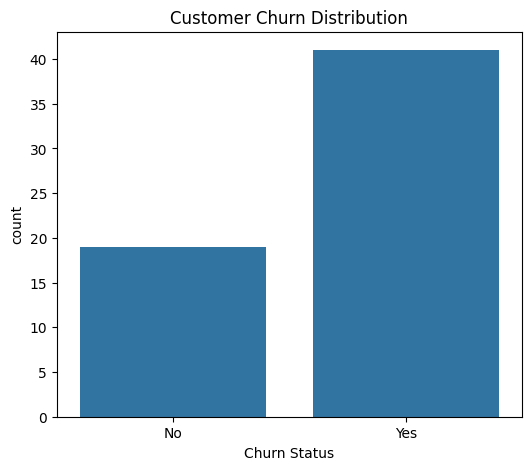

In [16]:
#Churn Distribution

plt.figure(figsize=(6,5))
sns.countplot(data=df,x='Churn Status')
plt.title("Customer Churn Distribution")
plt.show()

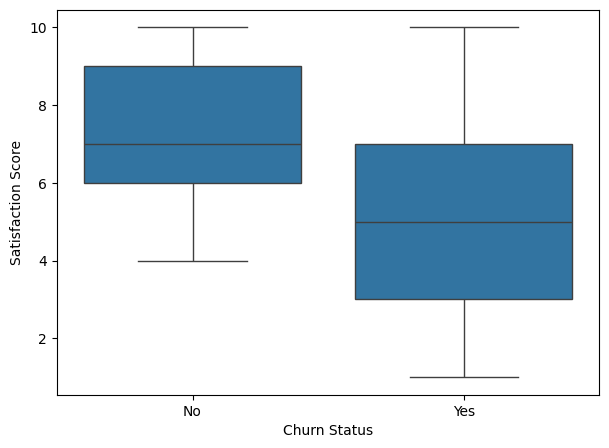

In [17]:
#Satisfaction Score vs Churn
plt.figure(figsize=(7,5))
sns.boxplot(x="Churn Status" , y= "Satisfaction Score" , data=df)
plt.show()

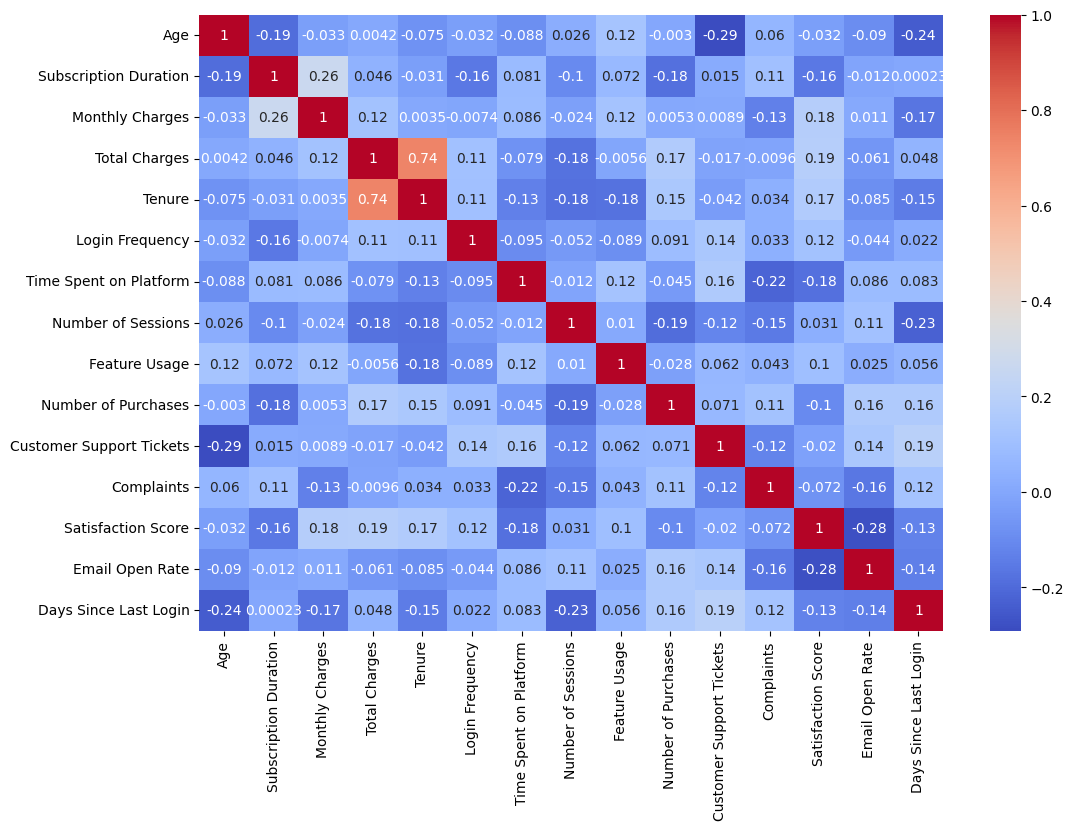

In [18]:
#Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64' , 'float64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True , cmap='coolwarm')
plt.show()

In [ ]:
#Encode Categorical variable
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype=='object':
        df[col] = encoder.fit_transform(df[col])

In [35]:
#Prepare Data

x= df.drop(columns=['Customer ID','Churn Status' , 'Last Login Date'])
y = df['Churn Status']
print(x)
print(y)

          Age  Gender   Location Subscription Type  Subscription Duration  \
0   58.000000    Male      Delhi           Premium                    6.0   
1   32.000000   Other    Chennai             Basic                   24.0   
2   37.423729    Male      Delhi          Standard                    1.0   
3   54.000000    Male  Hyderabad             Basic                    1.0   
4   60.000000    Male  Hyderabad           Premium                    1.0   
5   32.000000    Male       Pune          Standard                   12.0   
6   27.000000  Female     Mumbai             Basic                   24.0   
7   27.000000   Other     Mumbai           Premium                   12.0   
8   59.000000  Female      Delhi          Standard                   12.0   
9   27.000000  Female       Pune             Basic                   24.0   
10  23.000000   Other    Kolkata           premium                   24.0   
11  63.000000  Female    Kolkata           Premium                    6.0   

In [26]:
#Train Test Split
X_train , X_test , y_train , y_test = train_test_split(x , y , test_size=0.20,random_state=42)

In [29]:
le = LabelEncoder()
categorical_cols = x.select_dtypes(include='object').columns

for col in categorical_cols:
    x[col] = le.fit_transform(x[col].astype(str))

In [ ]:
#Train Random Forest Model
X = pd.get_dummies(x,drop_first=True)
X_train, X_test, y_train , y_test = train_test_split(X,y , test_size=0.2,random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [33]:
#Prediction
y_pre = model.predict(X_test)
print(y_pre)

['No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes']


In [36]:
#Accuracy
accuracy = accuracy_score(y_test,y_pre)
print("Accuracy: " , accuracy)

Accuracy:  0.75


In [37]:
#Classification Report
print(classification_report(y_test,y_pre))

              precision    recall  f1-score   support

          No       0.67      0.50      0.57         4
         Yes       0.78      0.88      0.82         8

    accuracy                           0.75        12
   macro avg       0.72      0.69      0.70        12
weighted avg       0.74      0.75      0.74        12



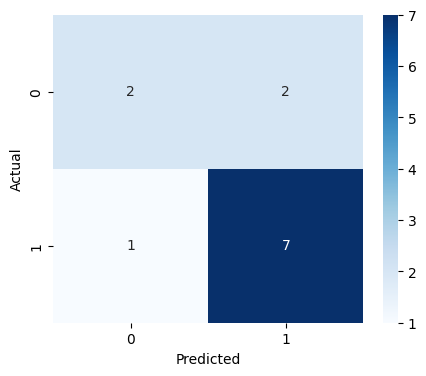

In [38]:
#Confusion Matrix
cm = confusion_matrix(y_test,y_pre)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap= 'Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
#Feature Importance

importance = pd.DataFrame({'Feature': X.columns , 'Importance': model.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
importance

,Feature,Importance
19,Days Since Last Login,0.212266
16,Satisfaction Score,0.156095
0,Age,0.089651
10,Time Spent on Platform,0.048270
4,Subscription Duration,0.048163
11,Number of Sessions,0.044891
5,Monthly Charges,0.040213
8,Tenure,0.037649
6,Total Charges,0.037563
12,Feature Usage,0.035733


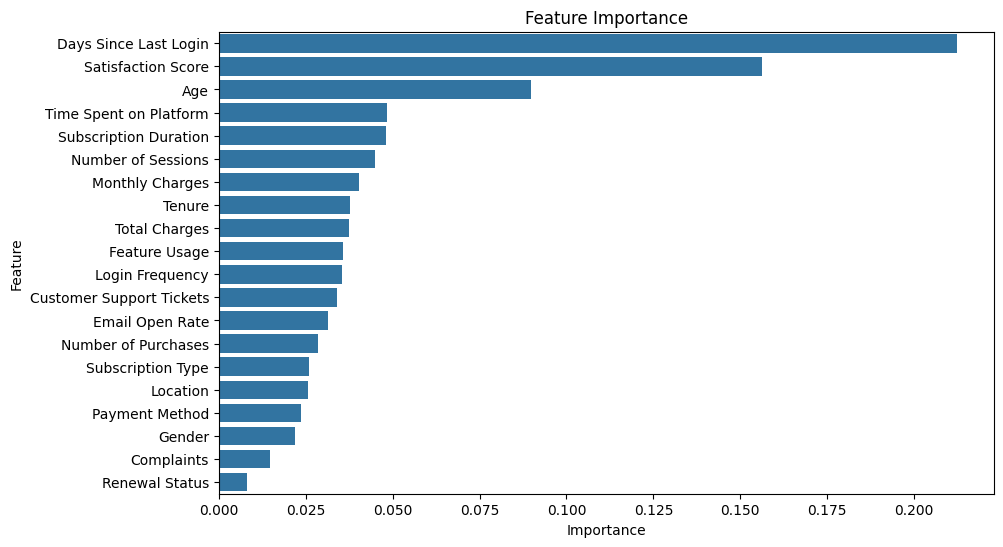

In [41]:
#Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(data= importance, x = 'Importance' , y = 'Feature')
plt.title("Feature Importance")
plt.show()

In [42]:
#Business Insights
print("Top Factors Affecting Customer Churn:\n")
print(importance.head(10))

Top Factors Affecting Customer Churn:

                   Feature  Importance
19   Days Since Last Login    0.212266
16      Satisfaction Score    0.156095
0                      Age    0.089651
10  Time Spent on Platform    0.048270
4    Subscription Duration    0.048163
11      Number of Sessions    0.044891
5          Monthly Charges    0.040213
8                   Tenure    0.037649
6            Total Charges    0.037563
12           Feature Usage    0.035733
